# Feature Engineering
## Gut Microbiome Project · Bar-Ilan University

Constructs clean, model-ready feature matrices for both datasets.

| | Dataset 1 — Food Microbiome (cFMD) | Dataset 2 — Human Gut Longitudinal |
|---|---|---|
| Samples | 4 344 food samples | ~350 day-to-day transitions |
| Target | `food_group` (10 classes) | DeltaCLR direction per target taxon |
| Core features | Genus-level abundance sums, phylum sums, diversity, fermented flag | DeltaCLR per taxon, ecosystem delta metrics, food exposure grams, nutrients |


In [1]:
import warnings
import re
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import entropy as sp_entropy
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score
from IPython.display import display

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

warnings.filterwarnings('once')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')

print(f'numpy  {np.__version__}  |  pandas  {pd.__version__}')
print(f'UMAP available: {UMAP_AVAILABLE}')

numpy  2.3.5  |  pandas  2.3.3
UMAP available: False


In [2]:
def find_repo_root() -> Path:
    candidates = [Path.cwd()] + list(Path.cwd().parents)
    for p in candidates:
        if (p / 'master_metadata.tsv').exists():
            return p
    raise FileNotFoundError(
        'Cannot locate master_metadata.tsv. '
        'Run this notebook from inside the project repository.'
    )

REPO_ROOT = find_repo_root()
DIET_ROOT = REPO_ROOT / 'dietstudy_analyses-master'
DIET_DATA = REPO_ROOT / 'dietstudy_data'

required = [
    REPO_ROOT / 'master_metadata.tsv',
    REPO_ROOT / 'master_taxonomic_profiles.tsv',
    DIET_ROOT / 'data' / 'maps' / 'food_map_no_soy.txt',
    DIET_ROOT / 'data' / 'microbiome' / 'processed_sample' / 'taxonomy_clr_s.txt',
    DIET_ROOT / 'data' / 'microbiome' / 'processed_sample' / 'taxonomy_norm_s.txt',
    DIET_DATA / 'diet' / 'nutrition_totals.txt',
]
for p in required:
    status = '\u2714' if p.exists() else '\u2718 MISSING'
    print(f'  {status}  {p.relative_to(REPO_ROOT)}')

  ✔  master_metadata.tsv
  ✔  master_taxonomic_profiles.tsv
  ✔  dietstudy_analyses-master\data\maps\food_map_no_soy.txt
  ✔  dietstudy_analyses-master\data\microbiome\processed_sample\taxonomy_clr_s.txt
  ✔  dietstudy_analyses-master\data\microbiome\processed_sample\taxonomy_norm_s.txt
  ✔  dietstudy_data\diet\nutrition_totals.txt


---
## Part 1 — Dataset 1: Food Microbiome (cFMD)

The cFMD dataset contains **4 344 food samples** profiled at the SGB (Species-level Genome Bin) level.
We reconstruct the merged microbiome-metadata table from the two master files,
aggregate abundance to the **genus** and **phylum** level, add per-sample diversity indices,
encode categorical variables, and select the most informative features.


### Step 1 · Load and Reconstruct Master Tables


In [3]:
meta_raw = pd.read_csv(REPO_ROOT / 'master_metadata.tsv', sep='\t', low_memory=False)
meta_raw['combined_id'] = (
    meta_raw['dataset_name'].astype(str) + '__' + meta_raw['sample_id'].astype(str)
)

def assign_food_group(row):
    s = ' '.join([
        str(row.get('category', '') or ''),
        str(row.get('type',     '') or ''),
        str(row.get('subtype',  '') or ''),
    ]).lower()
    if any(w in s for w in ['cheese','cheddar','mozzarella','brie','camembert',
                             'ricotta','gouda','parmesan','feta','pecorino',
                             'grana','raclette','manchego','gruyere']):
        return 'Cheese'
    if 'kefir' in s: return 'Kefir'
    if any(w in s for w in ['yogurt','yoghurt','skyr']): return 'Yogurt'
    if any(w in s for w in ['cocoa','cacao','chocolate','coffee',
                             'fermented seed','fermented bean']):
        return 'Cocoa / fermented seeds'
    if any(w in s for w in ['sauerkraut','kimchi','pickle',
                             'fermented vegetable','fermented veg','vegetable']):
        return 'Fermented vegetables'
    if any(w in s for w in ['beer','wine','beverage','juice','kombucha',
                             'drink','cider','vinegar','spirit','fermented drink']):
        return 'Beverages'
    if any(w in s for w in ['fish','seafood','salmon','tuna','shrimp',
                             'shellfish','prawn','squid','oyster','mussel','crab']):
        return 'Fish'
    if any(w in s for w in ['meat','beef','pork','poultry','chicken','turkey',
                             'sausage','salami','ham','lamb','veal','prosciutto',
                             'chorizo','bacon','mortadella','lard']):
        return 'Meat'
    if any(w in s for w in ['cow milk','bovine milk','raw milk','bulk milk']):
        return 'Cow milk'
    if any(w in s for w in ['milk','cream','butter','whey','dairy','colostrum','curd']):
        return 'Other dairy'
    return 'Other food'

meta_raw['food_group'] = meta_raw.apply(assign_food_group, axis=1)
meta_raw['fermented_binary'] = (
    meta_raw['fermented/non-fermented']
    .str.lower().str.contains('ferment', na=False).astype(int)
)

meta_clean = (
    meta_raw[['combined_id', 'food_group', 'fermented_binary', 'country']]
    .drop_duplicates('combined_id')
)
print(f'Metadata: {len(meta_clean):,} samples, {meta_clean["food_group"].nunique()} food groups')
display(meta_clean['food_group'].value_counts().rename('count').to_frame())

print('\nLoading taxonomy matrix (may take ~30 s)...')
tax_raw = pd.read_csv(REPO_ROOT / 'master_taxonomic_profiles.tsv', sep='\t', index_col=0)
print(f'Taxonomy: {tax_raw.shape[0]:,} SGBs  x  {tax_raw.shape[1]:,} samples')

common_ids = sorted(set(meta_clean['combined_id']) & set(tax_raw.columns))
print(f'Common samples (metadata \u2229 taxonomy): {len(common_ids):,}')
# Coerce all abundance values to float (some columns may be read as object)
tax_common = tax_raw[common_ids].apply(pd.to_numeric, errors='coerce').fillna(0)

Metadata: 3,441 samples, 10 food groups


,count
food_group,
Cheese,1698
Kefir,676
Other dairy,290
Meat,275
Other food,180
Fish,96
Beverages,78
Fermented vegetables,77
Cocoa / fermented seeds,50



Loading taxonomy matrix (may take ~30 s)...


C:\Users\winte\AppData\Local\Temp\ipykernel_19604\3090794494.py:54: DtypeWarning: Columns (823) have mixed types. Specify dtype option on import or set low_memory=False.
  tax_raw = pd.read_csv(REPO_ROOT / 'master_taxonomic_profiles.tsv', sep='\t', index_col=0)


Taxonomy: 5,057 SGBs  x  3,393 samples
Common samples (metadata ∩ taxonomy): 3,393


### Step 2 · Per-Sample Alpha Diversity Indices

Before aggregating by rank, we compute two alpha-diversity features on the raw SGB-level abundance:
- **Richness** — number of SGBs detected (abundance > 0).
- **Shannon entropy** — evenness of the microbial community distribution.


Diversity computed for 3,393 samples


,div_richness,div_shannon
count,3393.00,3393.00
mean,27.83,1.20
std,31.76,0.70
min,1.00,0.00
25%,9.00,0.70
50%,17.00,1.10
75%,37.00,1.66
max,629.00,4.20


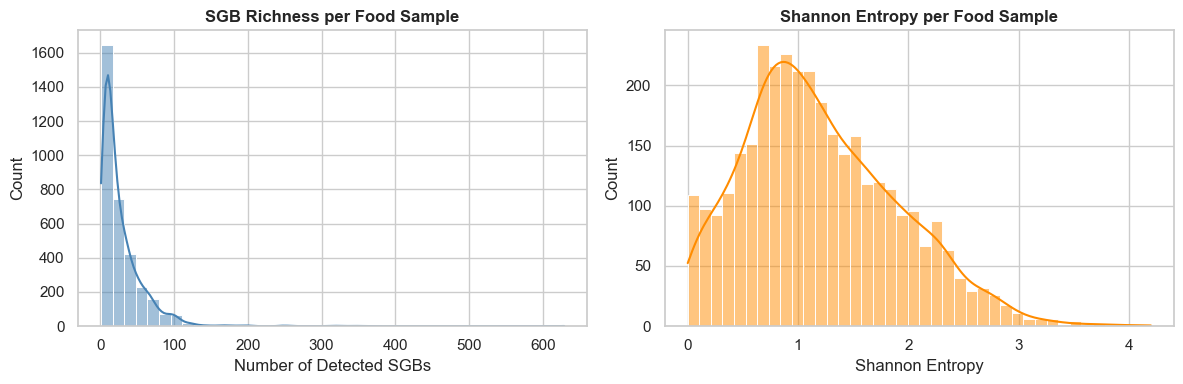

In [4]:
diversity_records = []
for sid in common_ids:
    abundances = tax_common[sid].dropna().values
    present    = abundances[abundances > 0]
    diversity_records.append({
        'combined_id':  sid,
        'div_richness': int(len(present)),
        'div_shannon':  float(sp_entropy(present)) if len(present) > 0 else 0.0,
    })

diversity_df = pd.DataFrame(diversity_records)
print(f'Diversity computed for {len(diversity_df):,} samples')
display(diversity_df.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(diversity_df['div_richness'], bins=40, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('SGB Richness per Food Sample', fontsize=12, weight='bold')
axes[0].set_xlabel('Number of Detected SGBs')
sns.histplot(diversity_df['div_shannon'], bins=40, ax=axes[1], color='darkorange', kde=True)
axes[1].set_title('Shannon Entropy per Food Sample', fontsize=12, weight='bold')
axes[1].set_xlabel('Shannon Entropy')
plt.tight_layout()
plt.show()

### Step 3 · Aggregate Taxonomy to Phylum and Genus Level

SGB taxonomy strings use pipe-separated rank labels: `k__|p__|c__|o__|f__|g__|s__|t__`.
We extract the **phylum** and **genus** label for each SGB row and sum abundances
across all SGBs sharing the same label.
This collapses ~5 000 SGB rows into ~50 phylum features and ~400 genus features.

**Country** is one-hot encoded (top 15 by frequency; rest → `Other`).
**Fermented binary** is already a 0/1 column from Step 1.


In [5]:
def extract_rank(taxonomy_str, rank_letter):
    prefix = f'{rank_letter}__'
    for part in str(taxonomy_str).split('|'):
        part = part.strip()
        if part.startswith(prefix):
            val = part[len(prefix):].strip()
            return val if val else 'Unknown'
    return 'Unknown'

tax_common = tax_common.copy()
tax_common['_Phylum'] = [extract_rank(t, 'p') for t in tax_common.index]
tax_common['_Genus']  = [extract_rank(t, 'g') for t in tax_common.index]

phylum_feats = (
    tax_common.groupby('_Phylum')[common_ids].sum()
    .drop(index='Unknown', errors='ignore')
    .T.add_prefix('phylum_')
)
genus_feats = (
    tax_common.groupby('_Genus')[common_ids].sum()
    .drop(index='Unknown', errors='ignore')
    .T.add_prefix('genus_')
)

# Country: top-15 + Other
top_countries = meta_clean['country'].value_counts().head(15).index
meta_clean = meta_clean.copy()
meta_clean['country_enc'] = meta_clean['country'].where(
    meta_clean['country'].isin(top_countries), other='Other'
)
country_dummies = pd.get_dummies(
    meta_clean.set_index('combined_id')['country_enc'], prefix='country', dtype=float
)

# Assemble raw feature matrix
meta_idx = meta_clean.set_index('combined_id')[['fermented_binary']]
X1_raw = (
    phylum_feats
    .join(genus_feats,     how='inner')
    .join(diversity_df.set_index('combined_id'), how='inner')
    .join(meta_idx,        how='inner')
    .join(country_dummies, how='inner')
)
y1_series = meta_clean.set_index('combined_id').loc[X1_raw.index, 'food_group']

print(f'Phylum features : {phylum_feats.shape[1]}')
print(f'Genus  features : {genus_feats.shape[1]}')
print(f'Diversity       : 2  (richness + Shannon)')
print(f'Fermented flag  : 1')
print(f'Country dummies : {country_dummies.shape[1]}')
print(f'\nRaw feature matrix X1: {X1_raw.shape}  (samples x features)')

Phylum features : 40
Genus  features : 1750
Diversity       : 2  (richness + Shannon)
Fermented flag  : 1
Country dummies : 16

Raw feature matrix X1: (3393, 1809)  (samples x features)


### Step 4 · Variance Threshold and Sparsity Filtering

Most genus columns are near-zero across all samples.
`VarianceThreshold` removes features with variance < 1e-6.
An additional **sparsity filter** removes features present in fewer than 5 % of samples,
further reducing noise.


Before variance filter :  1809 features
After VarianceThreshold:   952 features
After sparsity  filter :    86 features  (present in >=5% of samples)


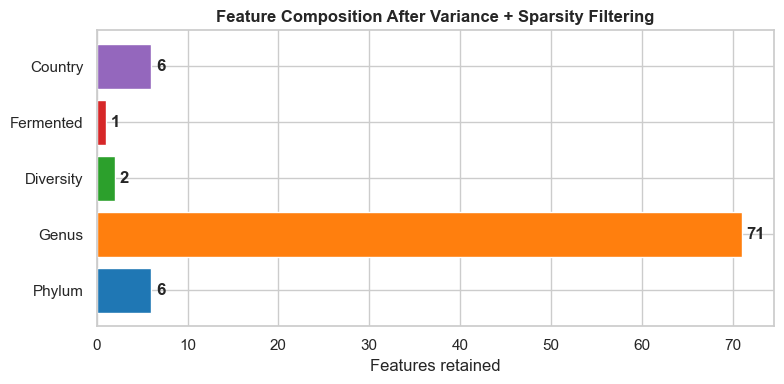

In [6]:
selector  = VarianceThreshold(threshold=1e-6)
X1_var    = selector.fit_transform(X1_raw.fillna(0))
kept_cols = X1_raw.columns[selector.get_support()]
X1_var_df = pd.DataFrame(X1_var, index=X1_raw.index, columns=kept_cols)

sparsity   = (X1_var_df == 0).mean()
dense_mask = sparsity < 0.95
X1_dense   = X1_var_df.loc[:, dense_mask]

# Preserve fermented_binary from X1_raw regardless of sparsity (used for visualization)
fermented_series = X1_raw.loc[X1_dense.index, 'fermented_binary']
if 'fermented_binary' not in X1_dense.columns:
    X1_dense = pd.concat([X1_dense, fermented_series.rename('fermented_binary')], axis=1)

print(f'Before variance filter : {X1_raw.shape[1]:>5} features')
print(f'After VarianceThreshold: {X1_var_df.shape[1]:>5} features')
print(f'After sparsity  filter : {X1_dense.shape[1]:>5} features  (present in >=5% of samples)')

breakdown = {
    'Phylum':    int(X1_dense.columns.str.startswith('phylum_').sum()),
    'Genus':     int(X1_dense.columns.str.startswith('genus_').sum()),
    'Diversity': int(X1_dense.columns.str.startswith('div_').sum()),
    'Fermented': int(X1_dense.columns.str.startswith('fermented').sum()),
    'Country':   int(X1_dense.columns.str.startswith('country_').sum()),
}
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('tab10', len(breakdown))
ax.barh(list(breakdown.keys()), list(breakdown.values()), color=colors)
for i, v in enumerate(breakdown.values()):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold')
ax.set_xlabel('Features retained')
ax.set_title('Feature Composition After Variance + Sparsity Filtering', weight='bold')
plt.tight_layout()
plt.show()

### Step 5 · PCA — Structure in Genus-Space

PCA is applied to the `StandardScaler`-normalized feature matrix.
We plot:
1. **Scree plot** — cumulative explained variance.
2. **PC1 vs PC2** colored by `food_group`.
3. **PC1 vs PC2** colored by fermentation status.


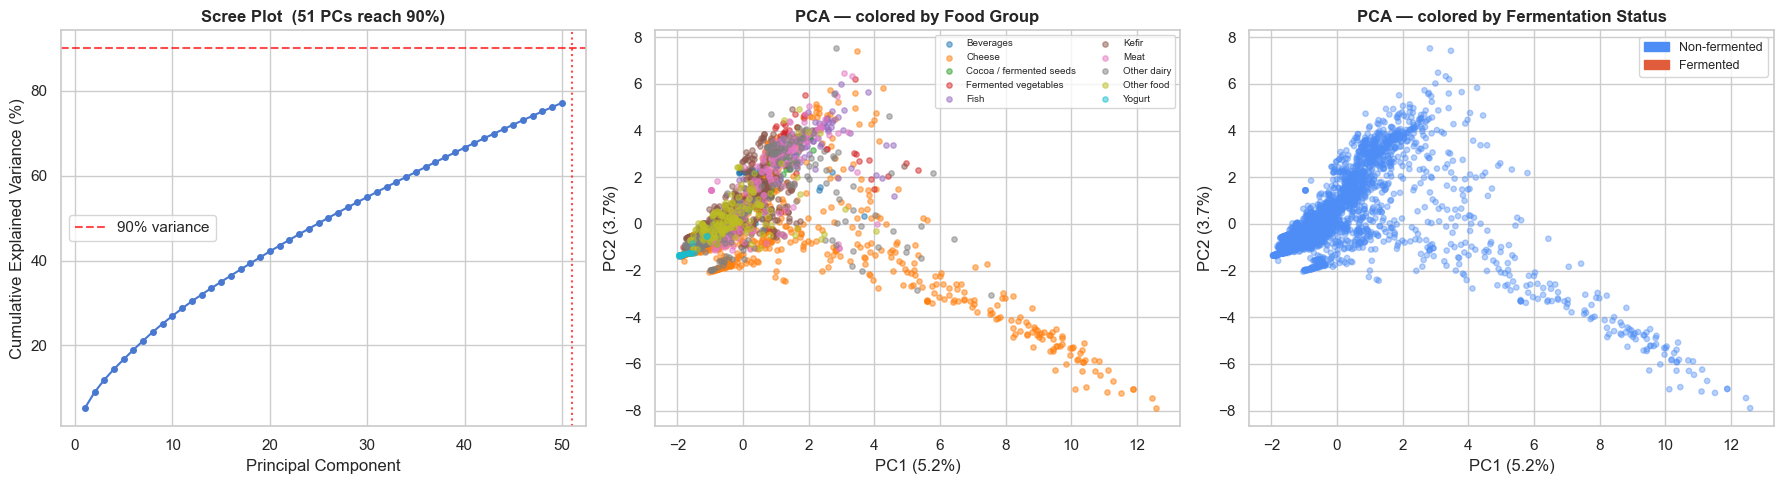

PC1 + PC2 explain 9.0% of total variance


In [7]:
scaler  = StandardScaler()
X1_sc   = scaler.fit_transform(X1_dense.fillna(0))

n_comp  = min(50, X1_sc.shape[1])
pca     = PCA(n_components=n_comp, random_state=RANDOM_SEED)
pca_fit = pca.fit_transform(X1_sc)

cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
n_90    = int(np.searchsorted(cum_var, 90)) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree
axes[0].plot(range(1, len(cum_var)+1), cum_var, marker='o', markersize=4, linewidth=1.5)
axes[0].axhline(90, color='red', linestyle='--', alpha=0.7, label='90% variance')
axes[0].axvline(n_90, color='red', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Cumulative Explained Variance (%)')
axes[0].set_title(f'Scree Plot  ({n_90} PCs reach 90%)', weight='bold')
axes[0].legend()

# PC1 vs PC2 — food_group
pca_df = pd.DataFrame({
    'PC1': pca_fit[:, 0], 'PC2': pca_fit[:, 1],
    'food_group': y1_series.values,
    'fermented':  X1_dense['fermented_binary'].values,
})
food_groups = sorted(pca_df['food_group'].unique())
palette     = dict(zip(food_groups, sns.color_palette('tab10', len(food_groups))))
for grp, g_df in pca_df.groupby('food_group'):
    axes[1].scatter(g_df['PC1'], g_df['PC2'],
                    label=grp, alpha=0.5, s=15, color=palette[grp])
axes[1].set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)')
axes[1].set_title('PCA — colored by Food Group', weight='bold')
axes[1].legend(fontsize=7, ncol=2)

# PC1 vs PC2 — fermented
colors_f = pca_df['fermented'].map({0: '#4e8df5', 1: '#e05c3a'})
axes[2].scatter(pca_df['PC1'], pca_df['PC2'], c=colors_f, alpha=0.4, s=15)
axes[2].legend(
    handles=[Patch(color='#4e8df5', label='Non-fermented'),
             Patch(color='#e05c3a', label='Fermented')], fontsize=9
)
axes[2].set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)')
axes[2].set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)')
axes[2].set_title('PCA — colored by Fermentation Status', weight='bold')

plt.tight_layout()
plt.show()
print(f'PC1 + PC2 explain {100*sum(pca.explained_variance_ratio_[:2]):.1f}% of total variance')

### Step 6 · UMAP Projection (Optional)

UMAP better preserves local neighbourhood structure than PCA for non-linear manifolds.
Install with `pip install umap-learn`. If unavailable the cell reports it and continues.


In [8]:
if UMAP_AVAILABLE:
    reducer     = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                             random_state=RANDOM_SEED, verbose=False)
    umap_coords = reducer.fit_transform(X1_sc)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    umap_df = pca_df.copy()
    umap_df['U1'] = umap_coords[:, 0]
    umap_df['U2'] = umap_coords[:, 1]
    for grp, g_df in umap_df.groupby('food_group'):
        axes[0].scatter(g_df['U1'], g_df['U2'],
                        label=grp, alpha=0.5, s=15, color=palette[grp])
    axes[0].set_title('UMAP — colored by Food Group', weight='bold')
    axes[0].legend(fontsize=7, ncol=2)
    axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2')

    colors_uf = umap_df['fermented'].map({0: '#4e8df5', 1: '#e05c3a'})
    axes[1].scatter(umap_coords[:, 0], umap_coords[:, 1], c=colors_uf, alpha=0.4, s=15)
    axes[1].legend(
        handles=[Patch(color='#4e8df5', label='Non-fermented'),
                 Patch(color='#e05c3a', label='Fermented')], fontsize=9
    )
    axes[1].set_title('UMAP — colored by Fermentation Status', weight='bold')
    axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
    plt.tight_layout()
    plt.show()
else:
    print('umap-learn not installed.  pip install umap-learn  to enable this visualization.')

umap-learn not installed.  pip install umap-learn  to enable this visualization.


### Step 7 · Feature Selection via Random Forest Importance

A balanced Random Forest (`n_estimators=300, max_depth=8`) is trained on all filtered
features to rank them by mean Gini impurity decrease.
We retain the **top 80 features** and show the top 25 in a ranked bar chart.


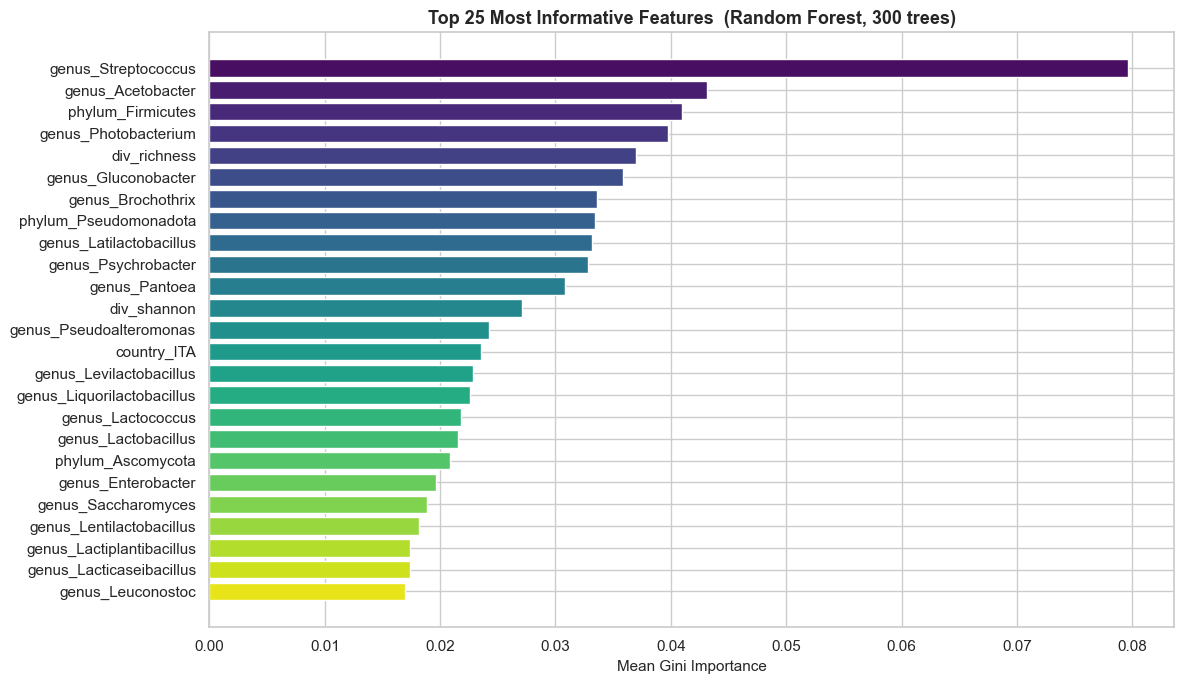

Top-80 feature breakdown by type:
  genus       : 66
  phylum      : 6
  country     : 6
  div         : 2


In [9]:
le    = LabelEncoder()
y1enc = le.fit_transform(y1_series)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
)
rf.fit(X1_dense.fillna(0), y1enc)

importances        = pd.Series(rf.feature_importances_, index=X1_dense.columns)
importances_sorted = importances.sort_values(ascending=False)
TOP_N              = 80
top_feats          = importances_sorted.head(TOP_N).index.tolist()

top25 = importances_sorted.head(25)
fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = sns.color_palette('viridis_r', 25)
ax.barh(top25.index[::-1], top25.values[::-1], color=colors_bar)
ax.set_xlabel('Mean Gini Importance', fontsize=11)
ax.set_title(
    f'Top 25 Most Informative Features  (Random Forest, {rf.n_estimators} trees)',
    weight='bold', fontsize=13
)
plt.tight_layout()
plt.show()

type_counts = {}
for f in top_feats:
    prefix = f.split('_')[0]
    type_counts[prefix] = type_counts.get(prefix, 0) + 1
print(f'Top-{TOP_N} feature breakdown by type:')
for k, v in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f'  {k:<12}: {v}')

### Step 8 · Final Feature Matrix — Dataset 1

The final Dataset 1 feature table:
- **Rows**: one per food sample
- **Columns**: top-80 RF-selected features + two target columns
- **Targets**: `food_group` (10-class), `fermented_binary` (binary)

Saved to `features_dataset1.csv` for use in `modeling.ipynb`.


In [10]:
X1_final = X1_dense[top_feats].copy()
X1_final.index.name = 'combined_id'
X1_final.insert(0, 'food_group',       y1_series.values)
X1_final.insert(1, 'fermented_binary', X1_dense['fermented_binary'].values)

X1_final.to_csv(REPO_ROOT / 'features_dataset1.csv')
print(f'Dataset 1 feature matrix: {X1_final.shape}  (samples x targets+features)')
print(f'Saved  ->  features_dataset1.csv')
display(X1_final.head(3))
print('\nClass balance (food_group):')
display(X1_final['food_group'].value_counts().rename('count').to_frame())

Dataset 1 feature matrix: (3393, 82)  (samples x targets+features)
Saved  ->  features_dataset1.csv


,food_group,fermented_binary,genus_Streptococcus,genus_Acetobacter,phylum_Firmicutes,genus_Photobacterium,div_richness,genus_Gluconobacter,genus_Brochothrix,phylum_Pseudomonadota,genus_Latilactobacillus,genus_Psychrobacter,genus_Pantoea,div_shannon,genus_Pseudoalteromonas,country_ITA,genus_Levilactobacillus,genus_Liquorilactobacillus,genus_Lactococcus,genus_Lactobacillus,phylum_Ascomycota,genus_Enterobacter,genus_Saccharomyces,genus_Lentilactobacillus,genus_Lactiplantibacillus,genus_Lacticaseibacillus,genus_Leuconostoc,genus_Paucilactobacillus,genus_Pseudomonas,genus_Pediococcus,genus_Limosilactobacillus,phylum_Bacteroidota,genus_Staphylococcus,genus_Acinetobacter,genus_Weissella,genus_Pichia,genus_Bacillus,genus_Debaryomyces,genus_Vibrio,country_Other,...,genus_Bifidobacterium,genus_Vagococcus,genus_Enterococcus,genus_Klebsiella,genus_Carnobacterium,genus_Flavobacterium,genus_Chryseobacterium,genus_Brevibacterium,country_ESP,genus_Macrococcoides,genus_Rahnella,country_IRL,genus_Serratia,genus_Rothia,genus_Escherichia,genus_Microbacterium,genus_Oenococcus,genus_Kocuria,genus_Corynebacterium,genus_Hafnia,genus_Citrobacter,genus_Brachybacterium,genus_Arthrobacter,genus_Raoultella,phylum_Deinococcota,genus_Moraxella,genus_Cutibacterium,genus_Companilactobacillus,genus_Glutamicibacter,genus_Mammaliicoccus,genus_Epilithonimonas,genus_Kluyvera,genus_Penicillium,genus_Loigolactobacillus,genus_Marinilactibacillus,country_AUT,genus_Halomonas,genus_Aeromonas,genus_Schleiferilactobacillus,genus_Tetragenococcus
combined_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AlmeidaO_2020__SRR8742576,Cocoa / fermented seeds,0,0.0,0.83973,15.42746,0.0,43.0,20.99698,0.0,83.23507,0.0,0.0,14.82217,2.458552,0.0,0.0,0.0,0.0,0.14109,0.0,0.89747,5.48767,0.89747,0.0,0.0,0.0,0.33599,0.0,0.0,0.0,14.74891,0.44000,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.13833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AlmeidaO_2020__SRR8742577,Cocoa / fermented seeds,0,0.0,0.15559,0.01121,0.0,31.0,2.80290,0.0,96.64845,0.0,0.0,0.91876,1.475530,0.0,0.0,0.0,0.0,0.00000,0.0,3.08870,0.15560,3.06707,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.00000,0.25166,0.0,0.0,0.0,0.02163,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.00798,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AlmeidaO_2020__SRR8742578,Cocoa / fermented seeds,0,0.0,0.00000,0.41319,0.0,26.0,0.17415,0.0,99.48988,0.0,0.0,35.46299,1.657388,0.0,0.0,0.0,0.0,0.40403,0.0,0.00000,8.33615,0.00000,0.0,0.0,0.0,0.00916,0.0,0.0,0.0,0.00000,0.09693,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.00994,0.08699,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Class balance (food_group):


,count
food_group,
Cheese,1690
Kefir,672
Other dairy,273
Meat,265
Other food,176
Fish,93
Beverages,77
Fermented vegetables,76
Cocoa / fermented seeds,50


---
## Part 2 — Dataset 2: Human Gut Longitudinal Study

The diet study tracked **32 participants** over ~17 days each (MCT oil vs EVOO arms).
Each **row** in the feature matrix represents a **T−1 → T transition**:
food consumed on day T−1 and the gut microbiome change measured on day T.


### Step 1 · Load All Data Sources


In [11]:
MAPS     = DIET_ROOT / 'data' / 'maps'
MICRO    = DIET_ROOT / 'data' / 'microbiome' / 'processed_sample'
FOOD_DIR = DIET_ROOT / 'data' / 'procrustes' / 'data_username_1day'

metadata2 = pd.read_csv(MAPS / 'food_map_no_soy.txt', sep='\t')
metadata2['#SampleID']    = metadata2['#SampleID'].astype(str)
metadata2['UserName']     = metadata2['UserName'].astype(str)
metadata2['StudyDayNo']   = pd.to_numeric(metadata2['StudyDayNo'], errors='coerce')
metadata2['Supplement_MCT'] = (metadata2['Supplement'].str.upper() == 'MCT').astype(int)

gut_clr  = pd.read_csv(MICRO / 'taxonomy_clr_s.txt',  sep='\t')
gut_norm = pd.read_csv(MICRO / 'taxonomy_norm_s.txt', sep='\t')
clr_samples  = [c for c in gut_clr.columns  if c != '#taxonomy']
norm_samples = [c for c in gut_norm.columns if c != '#taxonomy']
common_micro = sorted(set(clr_samples) & set(norm_samples))

food_logs = []
for fp in sorted(FOOD_DIR.glob('*_food.txt')):
    tmp = pd.read_csv(fp, sep='\t')
    sid_cols = [c for c in tmp.columns if c not in ['#FoodID', 'taxonomy']]
    tmp_long = tmp.melt(id_vars=['#FoodID', 'taxonomy'], value_vars=sid_cols,
                         var_name='#SampleID', value_name='Grams')
    tmp_long['Grams'] = pd.to_numeric(tmp_long['Grams'], errors='coerce')
    tmp_long = tmp_long.loc[tmp_long['Grams'] > 0]
    tmp_long['Food_Name'] = tmp_long['taxonomy'].apply(
        lambda t: str(t).split(';')[-1].strip() if pd.notna(t) else 'Unknown')
    food_logs.append(tmp_long)
diet_df2 = pd.concat(food_logs, ignore_index=True)
diet_df2['#SampleID'] = diet_df2['#SampleID'].astype(str)

nutrition = pd.read_csv(DIET_DATA / 'diet' / 'nutrition_totals.txt', sep='\t')
nutrition = nutrition.rename(columns={'X.SampleID': '#SampleID'})
nutrition['#SampleID'] = nutrition['#SampleID'].astype(str)
NUTR_COLS = ['KCAL', 'PROT', 'TFAT', 'CARB', 'FIBE']

print(f'Metadata    : {len(metadata2):,} rows, {metadata2["UserName"].nunique()} participants')
print(f'CLR matrix  : {gut_clr.shape[0]:,} taxa x {len(clr_samples):,} samples')
print(f'Diet events : {len(diet_df2):,} positive eating events')
print(f'Nutrition   : {len(nutrition):,} rows, {len(NUTR_COLS)} macro-nutrient columns')

Metadata    : 532 rows, 32 participants
CLR matrix  : 223 taxa x 483 samples
Diet events : 7,625 positive eating events
Nutrition   : 580 rows, 5 macro-nutrient columns


### Step 2 · Temporal Backbone and Ecosystem Delta Features

For each participant we sort samples by study day and pair each sample T
with its immediate predecessor T−1 (`DayGap == 1`). Per-sample ecological indices
(richness, Shannon entropy, Silhouette, CLR variance) are computed and differenced
to produce **delta features**. NORM presence/absence vectors yield taxon turnover counts.


In [12]:
def parse_rank_clr(taxonomy, rank_letter):
    for part in str(taxonomy).split(';'):
        part = part.strip()
        if part.startswith(f'{rank_letter}__'):
            val = part[3:].strip()
            return val if val else 'Unknown'
    return 'Unknown'

clr_long = gut_clr[['#taxonomy'] + common_micro].melt(
    id_vars='#taxonomy', var_name='#SampleID', value_name='CLR')
norm_long = gut_norm[['#taxonomy'] + common_micro].melt(
    id_vars='#taxonomy', var_name='#SampleID', value_name='NORM')
integrated = clr_long.merge(norm_long, on=['#taxonomy', '#SampleID'], how='inner')
integrated['Family'] = integrated['#taxonomy'].apply(lambda t: parse_rank_clr(t, 'f'))

eco_records = []
for sid, grp in integrated.groupby('#SampleID'):
    present = grp.loc[(grp['NORM'] > 0) & grp['NORM'].notna()]
    if present.empty:
        continue
    fam_ab  = present.groupby('Family')['NORM'].sum().values
    sil     = np.nan
    fam_lbl = present['Family'].astype(str)
    if 2 <= fam_lbl.nunique() < len(present):
        try:
            sil = float(silhouette_score(present[['CLR']].values, fam_lbl.values))
        except Exception:
            pass
    eco_records.append({
        '#SampleID':   sid,
        'NumTaxa':     present['#taxonomy'].nunique(),
        'NumFamilies': present['Family'].nunique(),
        'EntTaxa':     float(sp_entropy(present['NORM'].values)),
        'EntFamily':   float(sp_entropy(fam_ab)),
        'Silhouette':  sil,
        'CLRVar':      float(present['CLR'].var()),
    })

eco_df = pd.DataFrame(eco_records)
print(f'Ecological indices: {len(eco_df):,} samples')

backbone = metadata2[['#SampleID', 'UserName', 'StudyDayNo', 'Supplement_MCT']].copy()
backbone = backbone.sort_values(['UserName', 'StudyDayNo', '#SampleID'])
backbone['PrevSampleID']   = backbone.groupby('UserName')['#SampleID'].shift(1)
backbone['PrevStudyDayNo'] = backbone.groupby('UserName')['StudyDayNo'].shift(1)
backbone['DayGap']         = backbone['StudyDayNo'] - backbone['PrevStudyDayNo']

avail = set(eco_df['#SampleID'])
pairs = backbone.dropna(subset=['PrevSampleID'])
pairs = pairs.loc[
    pairs['#SampleID'].isin(avail) &
    pairs['PrevSampleID'].isin(avail) &
    pairs['DayGap'].eq(1)
].copy()
print(f'Valid T-1 -> T consecutive pairs: {len(pairs):,}')

eco_T   = eco_df.add_suffix('_T').rename(columns={'#SampleID_T': '#SampleID'})
eco_Tm1 = eco_df.add_suffix('_Tm1').rename(columns={'#SampleID_Tm1': '#SampleID'})
trans   = pairs.merge(eco_T,  on='#SampleID',    how='inner')
trans   = trans.merge(eco_Tm1, left_on='PrevSampleID', right_on='#SampleID',
                       how='inner', suffixes=('', '_drop'))
trans   = trans.loc[:, ~trans.columns.str.endswith('_drop')]

for m in ['NumTaxa', 'NumFamilies', 'EntTaxa', 'EntFamily', 'Silhouette', 'CLRVar']:
    trans[f'Delta_{m}'] = trans[f'{m}_T'] - trans[f'{m}_Tm1']

norm_wide = gut_norm.set_index('#taxonomy')[common_micro]
turnover  = []
for _, row in trans[['#SampleID', 'PrevSampleID']].iterrows():
    cur_p  = norm_wide[row['#SampleID']].gt(0)
    prev_p = norm_wide[row['PrevSampleID']].gt(0)
    turnover.append({'#SampleID': row['#SampleID'],
                     'NumGained': int((~prev_p & cur_p).sum()),
                     'NumGone':   int((prev_p & ~cur_p).sum())})
trans = trans.merge(pd.DataFrame(turnover), on='#SampleID', how='left')

delta_cols_d2 = [c for c in trans.columns if c.startswith('Delta_')]
print(f'Ecosystem delta features: {delta_cols_d2}')
display(trans[['#SampleID', 'UserName', 'DayGap'] + delta_cols_d2[:4] + ['NumGained', 'NumGone']].head(4))

Ecological indices: 483 samples
Valid T-1 -> T consecutive pairs: 350
Ecosystem delta features: ['Delta_NumTaxa', 'Delta_NumFamilies', 'Delta_EntTaxa', 'Delta_EntFamily', 'Delta_Silhouette', 'Delta_CLRVar']


,#SampleID,UserName,DayGap,Delta_NumTaxa,Delta_NumFamilies,Delta_EntTaxa,Delta_EntFamily,NumGained,NumGone
0,MCT.f.0003,MCTs01,1.0,-6,0,0.660123,0.823957,1,7
1,MCT.f.0004,MCTs01,1.0,5,1,-0.491749,-0.472610,6,1
2,MCT.f.0005,MCTs01,1.0,-6,-1,-0.057004,-0.200716,1,7
3,MCT.f.0006,MCTs01,1.0,2,-1,0.107166,0.189059,6,4


### Step 3 · DeltaCLR for Target Taxa

For each transition we extract the per-participant mean DeltaCLR
across all SGBs belonging to each of the **6 target genera**.
These are the primary modelling targets and also candidate predictors for other targets.


DeltaCLR features: ['dCLR_Bifidobacterium', 'dCLR_Faecalibacterium', 'dCLR_Akkermansia', 'dCLR_Bacteroides', 'dCLR_Prevotella', 'dCLR_Lactobacillus']


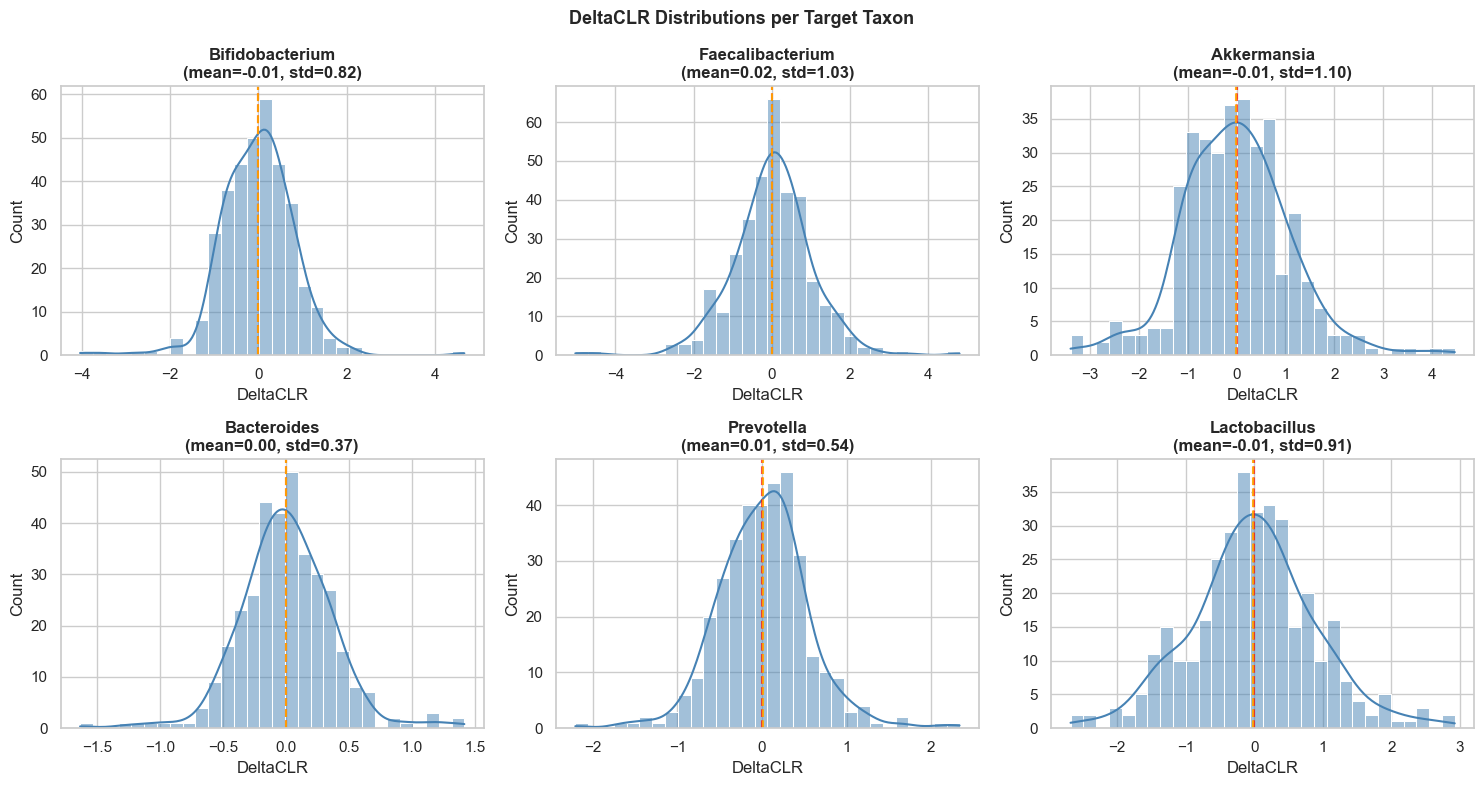

In [13]:
TARGET_TAXA = [
    'Bifidobacterium', 'Faecalibacterium', 'Akkermansia',
    'Bacteroides', 'Prevotella', 'Lactobacillus'
]

clr_long2  = clr_long.rename(columns={'CLR': 'CLR_T'})
clr_prev2  = clr_long.rename(columns={'CLR': 'CLR_Tm1', '#SampleID': 'PrevSampleID'})
tax_trans  = (
    pairs[['#SampleID', 'PrevSampleID', 'UserName', 'StudyDayNo']]
    .merge(clr_long2,  on='#SampleID',                   how='inner')
    .merge(clr_prev2, on=['PrevSampleID', '#taxonomy'],   how='inner')
)
tax_trans['DeltaCLR'] = tax_trans['CLR_T'] - tax_trans['CLR_Tm1']

taxa_feat_list = []
for taxon in TARGET_TAXA:
    rows = tax_trans.loc[tax_trans['#taxonomy'].str.contains(taxon, case=False, na=False)]
    if rows.empty:
        print(f'  WARNING: {taxon} not found in CLR taxonomy.')
        continue
    per_trans = (
        rows.groupby('#SampleID', as_index=False)['DeltaCLR'].mean()
        .rename(columns={'DeltaCLR': f'dCLR_{taxon}'})
    )
    taxa_feat_list.append(per_trans)

taxa_feats = reduce(lambda a, b: a.merge(b, on='#SampleID', how='outer'), taxa_feat_list)
trans       = trans.merge(taxa_feats, on='#SampleID', how='left')
dclr_cols   = [c for c in trans.columns if c.startswith('dCLR_')]

print(f'DeltaCLR features: {dclr_cols}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, dclr_cols):
    taxon_name = col.replace('dCLR_', '')
    vals = trans[col].dropna()
    sns.histplot(vals, bins=30, ax=ax, kde=True, color='steelblue')
    ax.axvline(0,           color='red',    linestyle='--', alpha=0.7)
    ax.axvline(vals.mean(), color='orange', linestyle='--', alpha=0.9)
    ax.set_title(f'{taxon_name}\n(mean={vals.mean():.2f}, std={vals.std():.2f})', weight='bold')
    ax.set_xlabel('DeltaCLR')
plt.suptitle('DeltaCLR Distributions per Target Taxon', weight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Step 4 · Food Exposure Features

Food diary entries at T−1 are grouped into **10 broad L1 categories** using keyword matching,
then pivoted into per-category gram totals per transition.
Days with no consumption in a category receive a value of **0**.


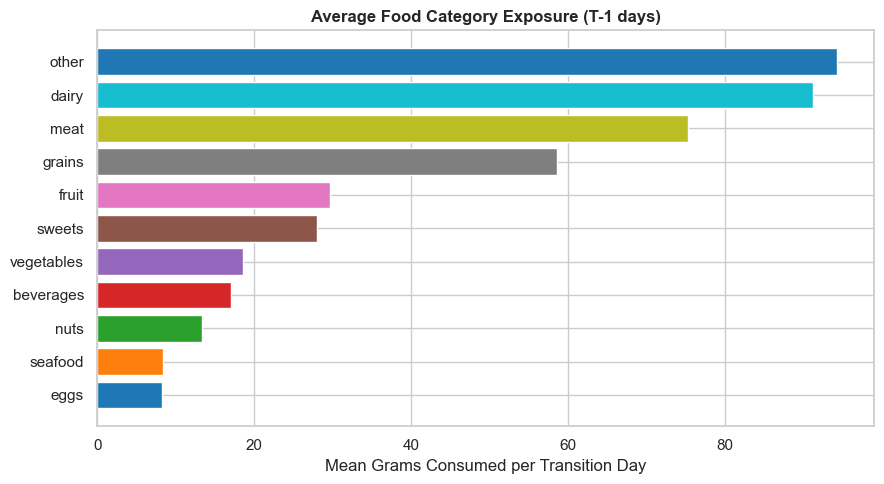

Food exposure features: ['food_beverages', 'food_dairy', 'food_eggs', 'food_fruit', 'food_grains', 'food_meat', 'food_nuts', 'food_other', 'food_seafood', 'food_sweets', 'food_vegetables']


In [14]:
def food_category(name):
    n = str(name).lower()
    if any(w in n for w in ['milk','cheese','yogurt','cream','dairy','butter','whey']):
        return 'food_dairy'
    if any(w in n for w in ['beef','pork','chicken','turkey','meat','sausage','ham','bacon','salami']):
        return 'food_meat'
    if any(w in n for w in ['fish','salmon','tuna','shrimp','seafood','prawn','oyster']):
        return 'food_seafood'
    if any(w in n for w in ['egg']):
        return 'food_eggs'
    if any(w in n for w in ['apple','banana','orange','berry','fruit','grape','peach','pear','mango','melon']):
        return 'food_fruit'
    if any(w in n for w in ['spinach','broccoli','carrot','tomato','lettuce','kale','cabbage','pepper','vegetable','salad']):
        return 'food_vegetables'
    if any(w in n for w in ['bread','rice','pasta','cereal','oat','grain','flour','cracker','wheat']):
        return 'food_grains'
    if any(w in n for w in ['chocolate','cookie','cake','sugar','candy','sweet','dessert']):
        return 'food_sweets'
    if any(w in n for w in ['coffee','tea','beer','wine','juice','soda','drink','water','beverage']):
        return 'food_beverages'
    if any(w in n for w in ['nut','almond','peanut','walnut','cashew','seed','tahini']):
        return 'food_nuts'
    return 'food_other'

diet_prev = diet_df2.rename(columns={'#SampleID': 'PrevSampleID'}).copy()
diet_prev['category'] = diet_prev['Food_Name'].apply(food_category)

food_exposure = (
    diet_prev.groupby(['PrevSampleID', 'category'])['Grams']
    .sum().unstack(fill_value=0).reset_index()
)
food_exposure.columns.name = None
trans = trans.merge(food_exposure, on='PrevSampleID', how='left')
food_cat_cols = [c for c in food_exposure.columns if c.startswith('food_')]
trans[food_cat_cols] = trans[food_cat_cols].fillna(0)

mean_exp = trans[food_cat_cols].mean().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(mean_exp.index.str.replace('food_', ''),
        mean_exp.values,
        color=sns.color_palette('tab10', len(mean_exp)))
ax.set_xlabel('Mean Grams Consumed per Transition Day')
ax.set_title('Average Food Category Exposure (T-1 days)', weight='bold')
plt.tight_layout()
plt.show()
print(f'Food exposure features: {food_cat_cols}')

### Step 5 · Nutrition Totals and Study-Design Variables

Macro-nutrient totals (KCAL, PROT, TFAT, CARB, FIBE) from day T−1 are joined
to each transition. Study-design variables included:
- `Supplement_MCT`: 1 = MCT oil arm, 0 = EVOO arm
- `StudyDayNo_norm`: normalized study day (0 → 1) to capture time-in-study effects


Nutrition features : ['nutr_KCAL', 'nutr_PROT', 'nutr_TFAT', 'nutr_CARB', 'nutr_FIBE']


,nutr_KCAL,nutr_PROT,nutr_TFAT,nutr_CARB,nutr_FIBE,Supplement_MCT,StudyDayNo_norm
count,350.00,350.00,350.00,350.00,350.00,350.00,350.00
mean,2140.69,89.34,91.90,232.48,23.11,0.53,0.49
std,774.99,38.96,41.52,88.90,12.16,0.50,0.31
min,722.55,23.45,20.47,45.05,3.62,0.00,0.00
25%,1600.53,61.88,61.03,173.37,15.02,0.00,0.20
50%,2043.07,83.84,83.37,220.06,20.22,1.00,0.47
75%,2520.82,106.88,117.69,277.23,28.42,1.00,0.78
max,5085.98,256.50,242.76,582.02,67.50,1.00,1.00


C:\Users\winte\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\winte\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\winte\AppData\Local\Temp\ipykernel_19604\777049703.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['EVOO', 'MCT'])
C:\Users\winte\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  a

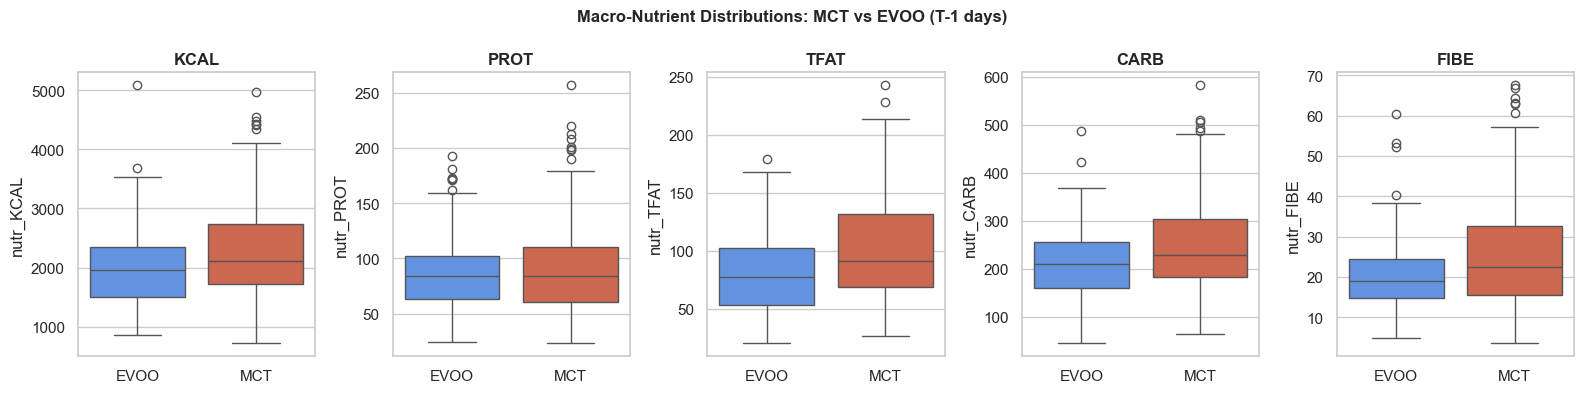

In [15]:
nutr_prev = (
    nutrition[['#SampleID'] + NUTR_COLS]
    .rename(columns={'#SampleID': 'PrevSampleID'})
    .add_prefix('nutr_')
    .rename(columns={'nutr_PrevSampleID': 'PrevSampleID'})
)
trans = trans.merge(nutr_prev, on='PrevSampleID', how='left')

day_min = trans['StudyDayNo'].min()
day_max = trans['StudyDayNo'].max()
trans['StudyDayNo_norm'] = (trans['StudyDayNo'] - day_min) / (day_max - day_min + 1e-9)

nutr_feat_cols = [f'nutr_{c}' for c in NUTR_COLS]
print(f'Nutrition features : {nutr_feat_cols}')
display(trans[nutr_feat_cols + ['Supplement_MCT', 'StudyDayNo_norm']].describe().round(2))

fig, axes = plt.subplots(1, len(NUTR_COLS), figsize=(16, 4))
for ax, col in zip(axes, nutr_feat_cols):
    sns.boxplot(data=trans, x='Supplement_MCT', y=col, ax=ax,
                hue='Supplement_MCT', palette=['#4e8df5', '#e05c3a'], legend=False)
    ax.set_xticklabels(['EVOO', 'MCT'])
    ax.set_xlabel('')
    ax.set_title(col.replace('nutr_', ''), weight='bold')
plt.suptitle('Macro-Nutrient Distributions: MCT vs EVOO (T-1 days)',
             weight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### Step 6 · Per-Participant Z-Score Normalization and Correlation Analysis

Raw DeltaCLR values may reflect inter-individual baseline differences rather than dietary effects.
**Per-participant Z-score normalization** (subtract participant mean, divide by std)
creates participant-comparable features.

The correlation heatmap reveals which diet and ecosystem variables co-vary,
guiding feature de-duplication in the modelling phase.


Z-score normalized features: 14


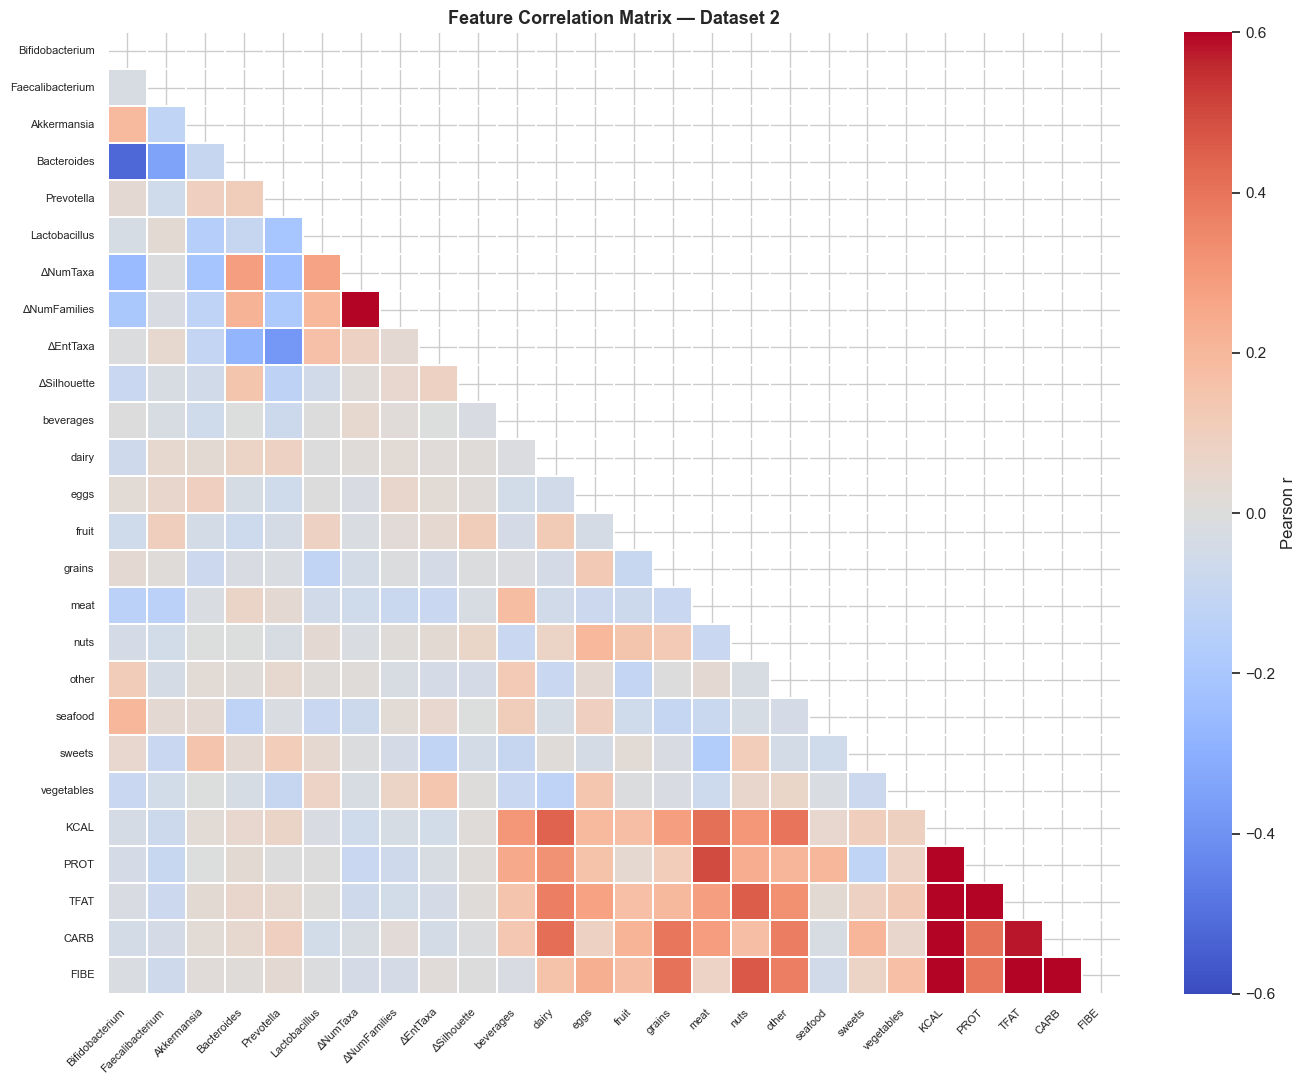


Top correlates with each DeltaCLR target:
  dCLR_Bifidobacterium: {'dCLR_Bacteroides': 0.5227170404264213, 'Delta_NumTaxa': 0.257543514971585, 'food_seafood': 0.20310505899121792}
  dCLR_Faecalibacterium: {'dCLR_Bacteroides': 0.34293587347293947, 'food_meat': 0.13903100537012011, 'dCLR_Akkermansia': 0.1217186670358605}
  dCLR_Akkermansia: {'Delta_NumTaxa': 0.2134888133042219, 'dCLR_Bifidobacterium': 0.19052634316548875, 'dCLR_Lactobacillus': 0.15871917971954455}
  dCLR_Bacteroides: {'dCLR_Bifidobacterium': 0.5227170404264213, 'dCLR_Faecalibacterium': 0.34293587347293947, 'Delta_NumTaxa': 0.2846533416923676}
  dCLR_Prevotella: {'Delta_EntTaxa': 0.3824261365100251, 'Delta_NumTaxa': 0.23569116957675632, 'dCLR_Lactobacillus': 0.2109187250454173}
  dCLR_Lactobacillus: {'Delta_NumTaxa': 0.2686926202043704, 'dCLR_Prevotella': 0.2109187250454173, 'Delta_NumFamilies': 0.19978740940438736}


In [16]:
norm_targets = delta_cols_d2 + dclr_cols + ['NumGained', 'NumGone']
trans_norm   = trans.copy()
for col in norm_targets:
    if col not in trans_norm.columns:
        continue
    trans_norm[col + '_z'] = trans_norm.groupby('UserName')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9)
    )

z_cols = [c for c in trans_norm.columns if c.endswith('_z')]
print(f'Z-score normalized features: {len(z_cols)}')

corr_features = (dclr_cols
    + ['Delta_NumTaxa', 'Delta_NumFamilies', 'Delta_EntTaxa', 'Delta_Silhouette']
    + food_cat_cols + nutr_feat_cols)
corr_features = [f for f in corr_features if f in trans_norm.columns]
corr_mat      = trans_norm[corr_features].corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_mat, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, vmin=-0.6, vmax=0.6, ax=ax,
            cbar_kws={'label': 'Pearson r'})
short = [c.replace('dCLR_','').replace('Delta_','\u0394').replace('food_','').replace('nutr_','')
         for c in corr_features]
ax.set_xticklabels(short, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short, rotation=0,  fontsize=8)
ax.set_title('Feature Correlation Matrix — Dataset 2', weight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTop correlates with each DeltaCLR target:')
for tc in dclr_cols:
    if tc not in corr_mat.columns:
        continue
    top3 = corr_mat[tc].drop(index=tc).abs().sort_values(ascending=False).head(3)
    print(f'  {tc}: {top3.to_dict()}')

### Step 7 · Final Feature Matrix — Dataset 2

| Feature group | Columns | Notes |
|---|---|---|
| Target taxa DeltaCLR | `dCLR_*` | Raw CLR shift per target genus |
| Target taxa DeltaCLR (Z) | `dCLR_*_z` | Per-participant normalized |
| Ecosystem deltas | `Delta_*` | Richness, entropy, Silhouette, variance |
| Taxon turnover | `NumGained`, `NumGone` | Taxa appearing / disappearing |
| Food exposure | `food_*` | Grams per L1 category at T−1 |
| Nutrition | `nutr_KCAL` … `nutr_FIBE` | Macro-nutrients at T−1 |
| Study design | `Supplement_MCT`, `StudyDayNo_norm` | Arm, time in study |

Saved to `features_dataset2.csv`.


In [17]:
ID_COLS = ['#SampleID', 'PrevSampleID', 'UserName', 'StudyDayNo']
FEAT_COLS = (
    dclr_cols
    + [c + '_z' for c in dclr_cols if c + '_z' in trans_norm.columns]
    + delta_cols_d2
    + [c + '_z' for c in delta_cols_d2 if c + '_z' in trans_norm.columns]
    + ['NumGained', 'NumGone']
    + food_cat_cols
    + nutr_feat_cols
    + ['Supplement_MCT', 'StudyDayNo_norm']
)
FEAT_COLS = [c for c in FEAT_COLS if c in trans_norm.columns]

X2_final = trans_norm[ID_COLS + FEAT_COLS].copy()
X2_final = X2_final.dropna(subset=dclr_cols, how='all')

X2_final.to_csv(REPO_ROOT / 'features_dataset2.csv', index=False)
print(f'Dataset 2 feature matrix: {X2_final.shape}  (transitions x ID+features)')
print(f'Participants             : {X2_final["UserName"].nunique()}')
mct = int(X2_final['Supplement_MCT'].sum())
print(f'MCT transitions          : {mct}  |  EVOO: {len(X2_final)-mct}')
print(f'Saved  ->  features_dataset2.csv')
display(X2_final[FEAT_COLS[:8]].head(3))

Dataset 2 feature matrix: (350, 48)  (transitions x ID+features)
Participants             : 32
MCT transitions          : 185  |  EVOO: 165
Saved  ->  features_dataset2.csv


,dCLR_Bifidobacterium,dCLR_Faecalibacterium,dCLR_Akkermansia,dCLR_Bacteroides,dCLR_Prevotella,dCLR_Lactobacillus,dCLR_Bifidobacterium_z,dCLR_Faecalibacterium_z
0,1.907347,1.346771,-0.631139,-1.633527,-0.764191,2.823175,1.907134,1.293334
1,-1.912258,1.192343,0.685968,1.123060,0.563586,-1.789868,-2.074033,1.117718
2,-0.342134,-0.881610,-2.500501,0.218773,0.494456,-0.180591,-0.437496,-1.240799


---
## Summary — Exported Feature Matrices

Both matrices are ready for `modeling.ipynb`.


In [18]:
files = [
    ('features_dataset1.csv',
     f'{X1_final.shape[0]} samples x {X1_final.shape[1]-2} features | '
     'targets: food_group, fermented_binary'),
    ('features_dataset2.csv',
     f'{X2_final.shape[0]} transitions x {len(FEAT_COLS)} features | '
     'targets: dCLR_* per target taxon'),
]
for fname, desc in files:
    fpath    = REPO_ROOT / fname
    size_kb  = fpath.stat().st_size / 1024
    print(f'{fname}')
    print(f'  {desc}')
    print(f'  {size_kb:.0f} KB')
    print()

features_dataset1.csv
  3393 samples x 80 features | targets: food_group, fermented_binary
  1481 KB

features_dataset2.csv
  350 transitions x 44 features | targets: dCLR_* per target taxon
  221 KB

